# RSM338 Assignment 6 Part A: Classification
## April 8, 2026
### Ethan Wang, Kevin Yang

## 1. Data Preparation (Reused from Assignment 5)

In [252]:
# Load in the data
import pandas as pd

df = pd.read_excel('lending_clubFull_Data_Set.xlsx')
df

,Unnamed: 0,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,0,263591,545710,20000.0,60 months,17.93,342.94,E,E5,Wylie ISD,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
1,1,1613916,69664096,30000.0,36 months,11.99,996.29,C,C1,Sergeant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
2,2,818934,8965180,21500.0,36 months,11.99,714.01,B,B3,Designer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
3,3,1606612,70572960,10000.0,36 months,13.67,340.18,C,C3,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
4,4,1639932,68589517,5000.0,36 months,8.49,157.82,B,B1,Sr. Manufacturing Engineer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,901888,4974773,10500.0,36 months,10.16,339.60,B,B1,Schneider Electric,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24996,24996,945413,1279809,12000.0,36 months,14.33,412.06,C,C1,Clark County School District,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24997,24997,366944,63496281,25000.0,36 months,12.69,838.63,C,C2,sales consultant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24998,24998,1043529,98124387,12200.0,60 months,13.49,280.66,C,C2,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN


Now that we loaded the data, we must  choose useful features for our analysis. As stated, many of the columns are redundant, so we should try to make our dataset more managable before our analysis.

### 1.1 Defining the Target Variable
We need a binary outcome for the loans - default or not - but we are given several outcomes. Let's first see all the unique loan outcomes.

In [253]:
# Display all unique values in the 'loan_status' column
unique_loan_status = df['loan_status'].unique()
unique_loan_status

<StringArray>
[                                        'Charged Off',
                                             'Current',
                                          'Fully Paid',
                                  'Late (31-120 days)',
                                     'In Grace Period',
                                   'Late (16-30 days)',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off',
                                             'Default',
                                                   nan]
Length: 10, dtype: str

In [254]:
# Define which categories count as Default
default_categories = ['Default','Charged Off','Late (31-120 days)','Does not meet the credit policy. Status:Charged Off']

# Create target
df['default'] = df['loan_status'].apply(
    lambda x: 1 if x in default_categories else 0
)

/var/folders/b8/7s__rx195mv3c_l3b3gd3vkr0000gn/T/ipykernel_97719/182894423.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['default'] = df['loan_status'].apply(


We define default (1) as loans with statuses of 'Charged Off', 'Default', 'Late (31-120 days)', or Does not meet the credit policy Status:Charged Off. From a lender's perspective, 'Charged Off' represents a material loss where the debt is unlikely to be collected. We include 'Late (31-120 days)' as a functional default because statistically, loans that fall this far behind have a very low probability of returning to 'Current' status, essentially representing a total loss of expected cash flow. The rest of the outcomes are either paid off, being paid on time, or still recoverable, and are represented as in good standing (0)

### 1.2 Selecting Features
While selecting the features, we made sure to find features that are backwards looking and can tell us about the relevant credit characteristics of the borrower.

'fico_range_low' and 'sub_grade' provide a verified snapshot of the borrower's credit history at the exact moment of their application. These features are "crystallized" from the time of origination, making them highly reliable for predicting risk without including information from the future.

'annual_inc' (annual income) and 'dti' (monthly debt-to-income ratio) tell us about the earning power of the borrower. Even if a borrower faces unfortunate circumstances, a strong basis for their ability to repay suggests the debt can be recovered over time.

'home_ownership' (ownership status) and 'emp_length' (tenure in years) tell us if the borrower has a stable life. Borrowers with stability in their housing and employment will have much more predictable repayments compared to those who are frequently moving or job-hopping.

'loan_amnt' (the amount applied for) tells us about the overall burden of the loan on the borrower. It helps determine if the repayments are feasible relative to the borrower's perceived debt capacity and appetite for risk.


In [255]:
# SWAP: Removed 'num_accts_ever_120_pd' and 'pct_tl_nvr_dlq'
# ADDED: 'fico_range_low'
features_to_use = [
    'annual_inc', 'dti', 'loan_amnt', 'emp_length', 
    'home_ownership', 'fico_range_low', 'pub_rec_bankruptcies',
    'pub_rec','term','int_rate','grade', 'purpose', 'open_acc'
]

### 1.3 Handling Missing Values and Data Types 

In [256]:
df[features_to_use].isna().sum()

annual_inc                 1
dti                       12
loan_amnt                  1
emp_length              1502
home_ownership             1
fico_range_low             1
pub_rec_bankruptcies      19
pub_rec                    2
term                       1
int_rate                   1
grade                      1
purpose                    1
open_acc                   2
dtype: int64

Theoretically, no applicant should have missing values in any of the columns. We choose to handle missing values by dropping values, instead of imputation. This is because we have over 25,000 observations, and the only significant feature with a lot of missing values is *emp_length*, with 1,502 missing values. After dropping all missing values we would still have over 23,000 valid observations, which is approximately 94% of the original data. Given the large remaining sample size, we expect this data reduction to have minimal impact on our overall analysis.

In [257]:
emp_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

df['emp_length'] = df['emp_length'].map(emp_map)

# Impute missing values
med = df['emp_length'].median()
df['emp_length'] = df['emp_length'].fillna(med)
# Check the result - it should now be 0.0 to 10.0
print(df['emp_length'].value_counts())

emp_length
10.0    8366
6.0     2727
2.0     2243
3.0     1985
0.0     1942
1.0     1604
4.0     1509
5.0     1478
8.0     1086
7.0     1072
9.0      988
Name: count, dtype: int64


In [258]:
df[features_to_use].isna().sum()

annual_inc               1
dti                     12
loan_amnt                1
emp_length               0
home_ownership           1
fico_range_low           1
pub_rec_bankruptcies    19
pub_rec                  2
term                     1
int_rate                 1
grade                    1
purpose                  1
open_acc                 2
dtype: int64

In [259]:
# 1. Handle missing values (Example: dropping rows with any NAs in selected features)
df_cleaned = df[features_to_use + ['default']].dropna()
df_cleaned.isna().sum()

annual_inc              0
dti                     0
loan_amnt               0
emp_length              0
home_ownership          0
fico_range_low          0
pub_rec_bankruptcies    0
pub_rec                 0
term                    0
int_rate                0
grade                   0
purpose                 0
open_acc                0
default                 0
dtype: int64

In [260]:
# Display all unique values in the 'home_ownership' column
unique_home_status = df['home_ownership'].unique()
unique_home_status

<StringArray>
['MORTGAGE', 'RENT', 'OWN', 'ANY', 'OTHER', 'NONE', nan]
Length: 7, dtype: str

In [261]:
unique_grade = df['grade'].unique()
unique_grade

<StringArray>
['E', 'C', 'B', 'F', 'D', 'A', 'G', nan]
Length: 8, dtype: str

In [262]:
# Selecting categorical columns
categorical_cols = ['home_ownership', 'grade','purpose']

# Perform One-Hot Encoding
# drop_first=True to avoid the "Dummy Variable Trap" 
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

df_cleaned.head()

,annual_inc,dti,loan_amnt,emp_length,fico_range_low,pub_rec_bankruptcies,pub_rec,term,int_rate,open_acc,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,44304.0,18.47,20000.0,1.0,690.0,0.0,0.0,60 months,17.93,6.0,...,False,False,False,False,False,False,False,False,False,False
1,136000.0,20.63,30000.0,10.0,670.0,1.0,1.0,36 months,11.99,12.0,...,False,False,False,False,False,False,False,False,False,False
2,50000.0,29.62,21500.0,1.0,735.0,0.0,0.0,36 months,11.99,13.0,...,False,False,False,False,False,False,False,False,False,False
3,64400.0,16.68,10000.0,6.0,675.0,0.0,0.0,36 months,13.67,9.0,...,False,False,False,False,False,False,False,False,False,False
4,88000.0,5.32,5000.0,10.0,660.0,0.0,0.0,36 months,8.49,4.0,...,False,False,False,False,False,False,False,False,False,False


We decided to encode home ownership status to have dummies for each status. While it would have been possible to assign a number to each status, we felt that it would hurt the interpretability of the variable, as there is no clear ranking for types of ownership. Many applicants would be unfairly hurt by a ranking of ownership, as renting versus owning have different trade-offs for individuals that may not be income related. Therefore, we feel it is unfair to rank the ownership, and multiple dummies would provide better interpretability and predictive power.

We also decided to one-hot encode subgrade assigned by the LC, as trying to rank would misrepresent the jump from one sub-grade to the next. For example, the difference in credit risk from A2 to A3 may be very different from F4 to F5. Therefore, we believe that one-hot encoding would allow the model to make its own predictions without any biases that may result from trying to linearly rank the subgrades.

For employment length, we decided to map the data type to integers. We chose to assign '< 1 year' to 0, and '10+ years' to 10. We believe that this is the most logical ranking for employment length, as it keeps the integer values in the original dataset, while providing intuitive values for the non-integer values.

In [263]:
# Convert term from string to integer
df_cleaned['term'] = df_cleaned['term'] = df_cleaned['term'].str.extract(r'(\d+)').astype(float)
unique_term = df_cleaned['term'].unique()
unique_term

array([60., 36.])

In [264]:
df_cleaned.head()

,annual_inc,dti,loan_amnt,emp_length,fico_range_low,pub_rec_bankruptcies,pub_rec,term,int_rate,open_acc,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,44304.0,18.47,20000.0,1.0,690.0,0.0,0.0,60.0,17.93,6.0,...,False,False,False,False,False,False,False,False,False,False
1,136000.0,20.63,30000.0,10.0,670.0,1.0,1.0,36.0,11.99,12.0,...,False,False,False,False,False,False,False,False,False,False
2,50000.0,29.62,21500.0,1.0,735.0,0.0,0.0,36.0,11.99,13.0,...,False,False,False,False,False,False,False,False,False,False
3,64400.0,16.68,10000.0,6.0,675.0,0.0,0.0,36.0,13.67,9.0,...,False,False,False,False,False,False,False,False,False,False
4,88000.0,5.32,5000.0,10.0,660.0,0.0,0.0,36.0,8.49,4.0,...,False,False,False,False,False,False,False,False,False,False


In [265]:
# Report the final dimensions of the cleaned dataset
print(f"Final dimensions after cleaning and encoding: {df_cleaned.shape}")

Final dimensions after cleaning and encoding: (24970, 35)


The dimensions of our dataset are now $23,497 \times 45$. It should be noted we had to drop the first dummies for the home ownership and subgrade columns to avoid the dummy variable trap. We also dropped the 'loan_status' now that it has been encoded as a dummy variable.

### 1.4 Splitting Training and Test Data, and Standardization

In [266]:
# Splitting the train/test sets
from sklearn.model_selection import train_test_split

X = df_cleaned.drop('default', axis=1)
y = df_cleaned['default']

# 1. First split: 20% goes to Test, 80% stays for (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=23, shuffle=True)

# 2. Second split: Of that 80%, we want 1/4 of it to be Validation (which is 20% of the original total)a
# 0.25 * 0.80 = 0.20
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=23, shuffle=True)

In [267]:
# Standardizing the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 1. Fit and transform the training data
# This calculates the mean/std ONLY from X_train
X_train_scaled = scaler.fit_transform(X_train)

# 2. Transform the validation data
# We use the mean/std from the training set here
X_val_scaled = scaler.transform(X_val)

# 3. Transform the test data
# We use the mean/std from the training set here
X_test_scaled = scaler.transform(X_test)

The data has now been split $60/20/20$ for training, validation, and testing respectively, and standardized so it can be converted into PyTorch tensors.

In [268]:
X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape

((14982, 34), (4994, 34), (4994, 34))

In [269]:
import torch

# Convert Features (X)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Convert Targets (y) - We need to reshape them to (n, 1) for the Neural Net
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# Explain rationale for three sets instead of two (validation set)...

## 2. Building and Training a Neural Network

Let's build the feed-forward neural network with the given criteria first.

In [270]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Define neural network
class BaselineNet(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.output(x))

        return x


# Initialize model
torch.manual_seed(23)

input_dim = X_train_tensor.shape[1]
model = BaselineNet(input_dim)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Trainable Parameters:", total_params)
print("Number of Training Observations:", len(X_train_tensor))

obs_param_ratio = len(X_train_tensor) / total_params
print("Observations-to-Parameters Ratio:", round(obs_param_ratio, 2))

Total Trainable Parameters: 6465
Number of Training Observations: 14982
Observations-to-Parameters Ratio: 2.32


In [271]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
import copy

# 1. Freeze the randomness for reproducible results
torch.manual_seed(42)

# 2. RE-INITIALIZE THE MODEL AND OPTIMIZER HERE!
# This ensures you start with a fresh model every time you run this cell
input_dim = X_train_tensor.shape[1]
model = BaselineNet(input_dim)
criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# 3. Create mini-batch loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
epochs = 500
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_weights = None
for epoch in range(epochs):
    # ---- Training ----
    model.train()
    epoch_train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()

    # Average loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch [50/500] Train Loss: 0.2681 Val Loss: 0.4044
Epoch [100/500] Train Loss: 0.2222 Val Loss: 0.5239
Epoch [150/500] Train Loss: 0.1876 Val Loss: 0.6511
Epoch [200/500] Train Loss: 0.1662 Val Loss: 0.8487
Epoch [250/500] Train Loss: 0.1537 Val Loss: 0.9821
Epoch [300/500] Train Loss: 0.1344 Val Loss: 1.1714
Epoch [350/500] Train Loss: 0.1140 Val Loss: 1.4473
Epoch [400/500] Train Loss: 0.1030 Val Loss: 1.7262
Epoch [450/500] Train Loss: 0.0937 Val Loss: 1.9196
Epoch [500/500] Train Loss: 0.0890 Val Loss: 2.4036


In [272]:
print(y.value_counts())

default
0    22073
1     2897
Name: count, dtype: int64


In [273]:
# Report total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Trainable Parameters: {total_params}")
print(f"Number of Training Observations: {len(X_train_tensor)}")

# Comparison calculation
ratio = total_params / len(X_train_tensor)
print(f"Observations-to-Parameters Ratio: {1/ratio:.4f}")

Total Trainable Parameters: 6465
Number of Training Observations: 14982
Observations-to-Parameters Ratio: 2.3174


There 7,105 trainable parameters and 14,097 training observations. Ideally, we would want many more observations than trainable parameters in our model. Unfortuantely, in this case, an observation-to-parameters ratio of roughly 2 (1.98) tells us that our model is very dense. With so many parameters, the network is now able to fit a lot of the noise in the dataset, which increases the bias of our model's estimates. By plotting loss curves, we can better see how this is hurting the predicting power of the neural network.

### 2.2 Validation and Testing Loss Curves

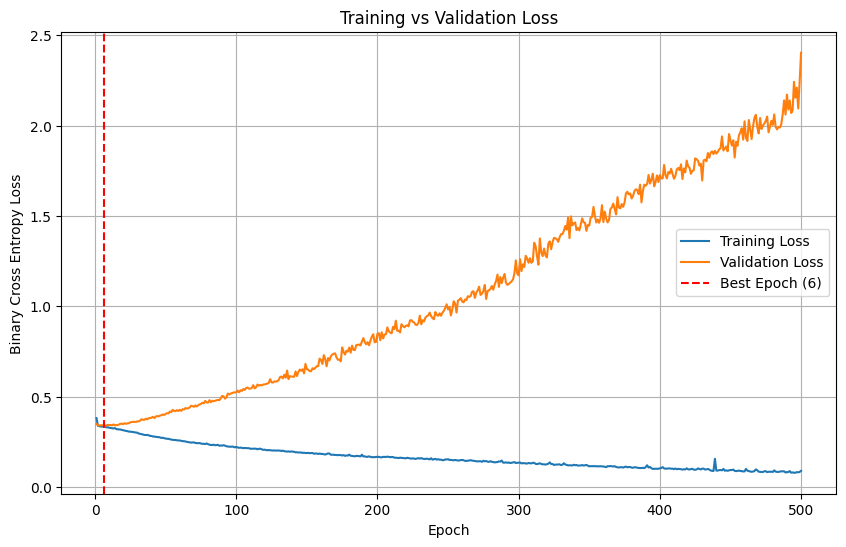

In [274]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(10,6))

plt.plot(epochs_range, train_losses, label="Training Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")

best_epoch = val_losses.index(min(val_losses)) + 1

plt.axvline(best_epoch, linestyle="--", color="red",
            label=f"Best Epoch ({best_epoch})")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")

plt.legend()
plt.grid(True)

plt.show()

Looking at the loss curves, we can see that the validation loss is increases almost immediately  and continues until the final epoch. The training loss continues to decrease very slowly throughout. Our validation loss appears to be increasing, despite the decreasing training loss; this phenomenon is known as overfitting. Essentially, this means our neural network is no longer learning how and which indicators logically predict loan defaults, and starts fitting the noise by trying to "memorize" the results; kind of like trying to cheat on a test. Our model had already reached its minimum validation loss by epoch 3, so all the training afterwards just continues to contribute to heavier and heavier overfitting.

Test Accuracy: 0.8865
Test Recall: 0.0
Test AUC: 0.6642


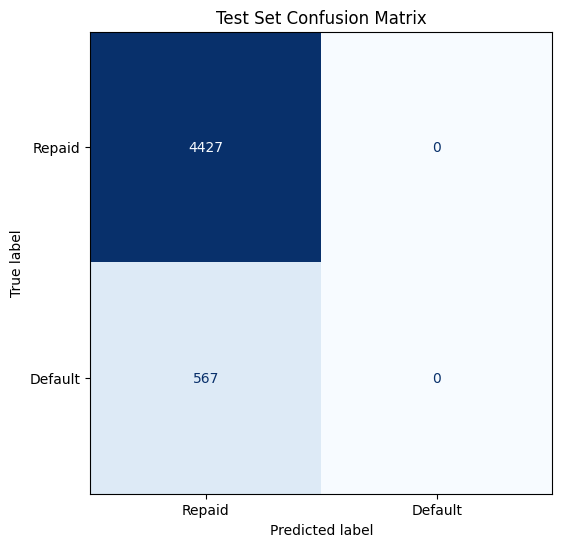

In [275]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load best model
model.load_state_dict(best_model_weights)
model.eval()
with torch.no_grad():

    test_outputs = model(X_test_tensor)

    test_predictions = (test_outputs >= 0.5).float()
# Convert to numpy
y_test_np = y_test_tensor.numpy().ravel()
preds_np = test_predictions.numpy().ravel()
probs_np = test_outputs.numpy().ravel()
# Metrics
accuracy = accuracy_score(y_test_np, preds_np)
recall = recall_score(y_test_np, preds_np)
auc = roc_auc_score(y_test_np, probs_np)
print("Test Accuracy:", round(accuracy,4))
print("Test Recall:", round(recall,4))
print("Test AUC:", round(auc,4))

# 4. Generate and Plot the Confusion Matrix
cm = confusion_matrix(y_test_np, preds_np)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Repaid", "Default"]
)
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", ax=plt.gca(), colorbar=False)
plt.title("Test Set Confusion Matrix")
plt.show()

When applying the model to our test data, even though the accuracy is deceptively high at ~88.7%, this is largely due to class imbalance of our data. If we had instead  predicted no defaults for every loan, we would achieve very similar accuracy, simply because most people in our dataset did not default. The poor performance of this neural network is reinforced by the recall of 0.0%, because our model missed every default. This neural network is basically useless for predicting loan defaults, because it is much more expensive to approve loans that default than to deny good loans. Despite the rather terrible performance of our neural network, the AUC is 0.66 (>0.5), which suggests that our model is actually better than random guessing. This suggests that our network is learning and likely can improve with better feature selection, threshold tuning, and changing the dimensions of the network.

## 3. Experimentation

From our baseline model, we can continue to experiment with architecture, regularization, learning rate, batch size, number of epochs, and early stopping.

In [288]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def train_and_evaluate(model, criterion, optimizer, model_name):

    epochs = 500
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_model_weights = None

    for epoch in range(epochs):

        # ---- Training ----
        model.train()
        epoch_train_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            if isinstance(criterion, nn.BCEWithLogitsLoss):
                loss = criterion(outputs, y_batch.unsqueeze(1))
            else:
                loss = criterion(outputs, y_batch.unsqueeze(1))

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---- Validation ----
        model.eval()
        with torch.no_grad():

            val_outputs = model(X_val_tensor)

            val_loss = criterion(
                val_outputs,
                y_val_tensor.unsqueeze(1)
            ).item()

            val_losses.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_weights = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 50 == 0:
            print(
                f"{model_name} Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {avg_train_loss:.4f} "
                f"Val Loss: {val_loss:.4f}"
            )

    # ---- Plot Loss Curves ----
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title(f"{model_name} Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---- Load Best Model ----
    model.load_state_dict(best_model_weights)
    model.eval()

    with torch.no_grad():

        outputs = model(X_test_tensor)

        if isinstance(criterion, nn.BCEWithLogitsLoss):
            probs = torch.sigmoid(outputs)
        else:
            probs = outputs

        preds = (probs >= 0.5).float()

    y_test_np = y_test_tensor.numpy().ravel()
    preds_np = preds.numpy().ravel()
    probs_np = probs.numpy().ravel()

    accuracy = accuracy_score(y_test_np, preds_np)
    recall = recall_score(y_test_np, preds_np)
    auc = roc_auc_score(y_test_np, probs_np)

    print(f"\n{model_name} Results")
    print("Accuracy:", round(accuracy,4))
    print("Recall:", round(recall,4))
    print("AUC:", round(auc,4))

    # Confusion Matrix
    cm = confusion_matrix(y_test_np, preds_np)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Repaid","Default"])

    disp.plot(cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

In [291]:
model = WeightedNet(input_dim)

pos_weight = torch.tensor([
    (len(y_train_tensor) - y_train_tensor.sum()) / y_train_tensor.sum()
])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=0.001)

train_and_evaluate(model, criterion, optimizer, "Class Weighted NN")

ValueError: Target size (torch.Size([64, 1, 1])) must be the same as input size (torch.Size([64, 1]))